# Project 6 — Notebook 20: Preventive Maintenance Priority Engine

**Scope:** NCR (Region 3) — same cleaned dataset as NB19.

**Purpose:**  
NB19 identified *where* infrastructure is stressed. This notebook translates that into a **ranked, actionable PM work queue** with resource-allocation guidance per zone.  
It also cross-references the Project 5 site risk scores to confirm consistency.

**Questions answered:**
1. Which sites should be prioritised for PM intervention and why?
2. How many Critical/High PM candidates exist per zone, and what is the estimated workload?
3. Which NE types at PM-priority sites are driving the breach?
4. Are repeat-failure sites adequately captured by the PM score?

**Outputs:** `pm_priority_queue.csv`

---

## 1. Setup

In [1]:
import sys, os
os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

from src.projects.project6_infra import (
    build_pm_priority_queue,
    compute_site_complexity,
    compute_pm_priority_score,
    identify_repeat_failures,
)
from config import ZONE_PALETTE, DEFAULT_DPI

FIGURE_DIR = 'reports/figures/project6_ncr'
os.makedirs(FIGURE_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': DEFAULT_DPI, 'axes.spines.top': False, 'axes.spines.right': False})

BAND_COLORS = {'Critical': '#c0392b', 'High': '#e67e22', 'Medium': '#f1c40f', 'Low': '#2ecc71'}

## 2. Load & Build PM Queue

> **Note:** `build_pm_priority_queue()` passes the full `df` to `compute_site_complexity()`.
> Confirm that MTTR within `project6_infra.py` is computed on Field_Dispatch_Restored tickets
> only — this matches NB16's approach where `df_fd` is used for MTTR and SLA dimensions.
> Auto-Restored tickets (MTTR ≈ 0h) should be excluded to avoid underscoring sites with
> mixed resolution paths (most critical in Zone 4: 11.4% auto-restore, Zone 5: 12.8%).

In [2]:
df = pd.read_csv('output/cleaned_fault_ticket.csv', low_memory=False)
df = df[df['Region'] == 'Region 3'].copy()
print(f"NCR tickets loaded: {len(df):,}")

# Build full PM queue (default threshold = 70)
pm_queue = build_pm_priority_queue(df, score_threshold=70)

print(f"\nPM candidates (score ≥ 70): {len(pm_queue)}")
print(pm_queue['PM_Score_Band'].value_counts().to_string())
pm_queue.to_csv('output/pm_priority_queue.csv', index=False)

NCR tickets loaded: 38,319

PM candidates (score ≥ 70): 28
PM_Score_Band
High        25
Critical     3
Low          0
Medium       0


In [3]:
# Also compute full site table to understand score distribution
site_cx = compute_site_complexity(df)
site_scored = compute_pm_priority_score(site_cx)

print("Score distribution across ALL sites (≥5 tickets):")
eligible = site_scored[site_scored['Ticket_Count'] >= 10]
print(eligible['PM_Score_Band'].value_counts().to_string())
print(f"\nScore stats: mean={eligible['PM_Score'].mean():.1f}  "
      f"median={eligible['PM_Score'].median():.1f}  "
      f"max={eligible['PM_Score'].max():.1f}")

# ── Cross-reference: P5 site risk scores vs P6 PM scores ─────────────────────
# NB16 saves output/p5_site_risk_scores.csv — load and merge for rank validation
try:
    import scipy.stats as stats
    p5_risk = pd.read_csv('output/p5_site_risk_scores.csv')[['SiteName', 'Risk_Score']]
    compare = site_scored.merge(p5_risk, on='SiteName', how='inner')
    compare = compare[compare['Ticket_Count'] >= 10].dropna(subset=['Risk_Score', 'PM_Score'])
    if len(compare) >= 10:
        rho, pval = stats.spearmanr(compare['Risk_Score'], compare['PM_Score'])
        print(f"\nP5 vs P6 rank correlation (Spearman ρ): {rho:.3f}  (p={pval:.4f}, n={len(compare)} sites)")
        if rho >= 0.70:
            print("  ✅ Strong agreement — P5 and P6 models are consistent.")
        elif rho >= 0.50:
            print("  ⚠️  Moderate agreement — review boundary sites (NE_Count 5–7, score 60–75).")
        else:
            print("  ❌ Weak agreement — investigate scoring dimension differences.")
    else:
        print("Insufficient overlapping sites for Spearman comparison.")
except FileNotFoundError:
    print("⚠️  output/p5_site_risk_scores.csv not found — run NB16 first to generate P5 risk scores.")
except ImportError:
    print("scipy not available — install with: pip install scipy")

Score distribution across ALL sites (≥5 tickets):
PM_Score_Band
Low         893
Medium      116
High         21
Critical      0

Score stats: mean=35.5  median=32.2  max=78.4

P5 vs P6 rank correlation (Spearman ρ): 0.692  (p=0.0000, n=1025 sites)
  ⚠️  Moderate agreement — review boundary sites (NE_Count 5–7, score 60–75).


## 3. PM Queue — Top Candidates

> **PM Score formula** (`compute_pm_priority_score` in `project6_infra.py`):
> - Breach_Rate × 0.30
> - Avg_MTTR (normalised) × 0.25
> - Ticket_Count (normalised) × 0.20
> - Repeat_Failure_Ratio × 0.15
> - Complexity tier (High=100, Medium=50, Low=0) × 0.10
> - +5 bonus if Has_Core_IP = True
>
> **Difference from P5 Risk Score (NB16):** P6 adds `Repeat_Failure_Ratio` as an explicit
> dimension and uses normalised global scores rather than within-zone percentile ranks.
> Repeat-failure sites therefore score higher in P6 than in P5, which is intentional —
> P6's PM engine is designed to surface chronic failures that P5's zone-relative ranking
> may have deprioritised within low-stress zones.

In [4]:
display_cols = ['PM_Rank','SiteName','ZONE','CITY','PM_Score','PM_Score_Band',
                'Ticket_Count','Avg_MTTR','Breach_Rate','NE_Type_Count',
                'Complexity_Tier','Repeat_Failure_Ratio','Has_Core_IP']
display_cols = [c for c in display_cols if c in pm_queue.columns]

print("Top 30 PM Priority Sites:")
display(
    pm_queue[display_cols].head(30)
    .style
    .format({
        'Avg_MTTR': '{:.1f}h',
        'Breach_Rate': '{:.1%}',
        'Repeat_Failure_Ratio': '{:.1%}',
        'PM_Score': '{:.1f}',
    })
    .apply(lambda row: [
        'background-color: #ffd6d6' if row.get('PM_Score_Band') == 'Critical' else
        'background-color: #ffe9cc' if row.get('PM_Score_Band') == 'High' else ''
        for _ in row
    ], axis=1)
    .background_gradient(subset=['PM_Score'], cmap='YlOrRd')
)

Top 30 PM Priority Sites:


,PM_Rank,SiteName,ZONE,CITY,PM_Score,PM_Score_Band,Ticket_Count,Avg_MTTR,Breach_Rate,NE_Type_Count,Complexity_Tier,Repeat_Failure_Ratio,Has_Core_IP
0,1,Region3_QUEZON CITY_9c1be50e,ZONE 2,QUEZON CITY,85.5,Critical,4,1099.8h,100.0%,1,Low,100.0%,False
1,2,Region3_TAGUIG CITY_794c2dbb,ZONE 5,TAGUIG CITY,85.5,Critical,3,185.6h,100.0%,1,Low,100.0%,False
2,3,Region3_VALENZUELA CITY_8cfe0d8c,ZONE 1,VALENZUELA CITY,80.8,Critical,3,137.0h,100.0%,1,Low,100.0%,False
3,4,Region3_QUEZON CITY_42af7f8c,ZONE 2,QUEZON CITY,78.8,High,3,445.7h,66.7%,1,Low,100.0%,True
4,5,Region3_PARANAQUE CITY_897d6665,ZONE 6,PARANAQUE CITY,78.4,High,10,834.9h,70.0%,3,Medium,90.0%,True
5,6,Region3_VALENZUELA CITY_5c81dff4,ZONE 1,VALENZUELA CITY,78.1,High,9,354.0h,77.8%,2,Low,100.0%,False
6,7,Region3_MUNTINLUPA CITY_ab63e7dc,ZONE 6,MUNTINLUPA CITY,76.7,High,4,195.8h,75.0%,1,Low,100.0%,False
7,8,Region3_CALOOCAN CITY_d55228fa,ZONE 1,CALOOCAN CITY,76.7,High,4,204.9h,75.0%,1,Low,100.0%,False
8,9,Region3_MAKATI CITY_bcdeac6a,ZONE 5,MAKATI CITY,74.6,High,14,879.9h,71.4%,3,Medium,92.9%,False
9,10,Region3_MANILA CITY_54372059,ZONE 4,MANILA CITY,74.5,High,8,208.0h,75.0%,3,Medium,87.5%,False


## 4. PM Workload by Zone

In [5]:
if 'ZONE' in pm_queue.columns:
    zone_workload = pm_queue.groupby('ZONE').agg(
        Total_PM_Sites    = ('SiteName', 'count'),
        Critical_Sites    = ('PM_Score_Band', lambda x: (x == 'Critical').sum()),
        High_Sites        = ('PM_Score_Band', lambda x: (x == 'High').sum()),
        Avg_PM_Score      = ('PM_Score', 'mean'),
        Max_PM_Score      = ('PM_Score', 'max'),
        Total_Tickets     = ('Ticket_Count', 'sum'),
        Avg_Breach        = ('Breach_Rate', 'mean'),
    ).reset_index()

    print("PM workload by zone:")
    display(zone_workload.style.format({
        'Avg_PM_Score': '{:.1f}',
        'Max_PM_Score': '{:.1f}',
        'Avg_Breach': '{:.1%}',
    }).background_gradient(subset='Critical_Sites', cmap='Reds'))

PM workload by zone:


,ZONE,Total_PM_Sites,Critical_Sites,High_Sites,Avg_PM_Score,Max_PM_Score,Total_Tickets,Avg_Breach
0,ZONE 1,4,1,3,76.8,80.8,21,78.2%
1,ZONE 2,4,1,3,76.5,85.5,18,74.7%
2,ZONE 4,3,0,3,72.5,74.5,22,67.2%
3,ZONE 5,15,1,14,72.9,85.5,98,72.2%
4,ZONE 6,2,0,2,77.6,78.4,14,72.5%


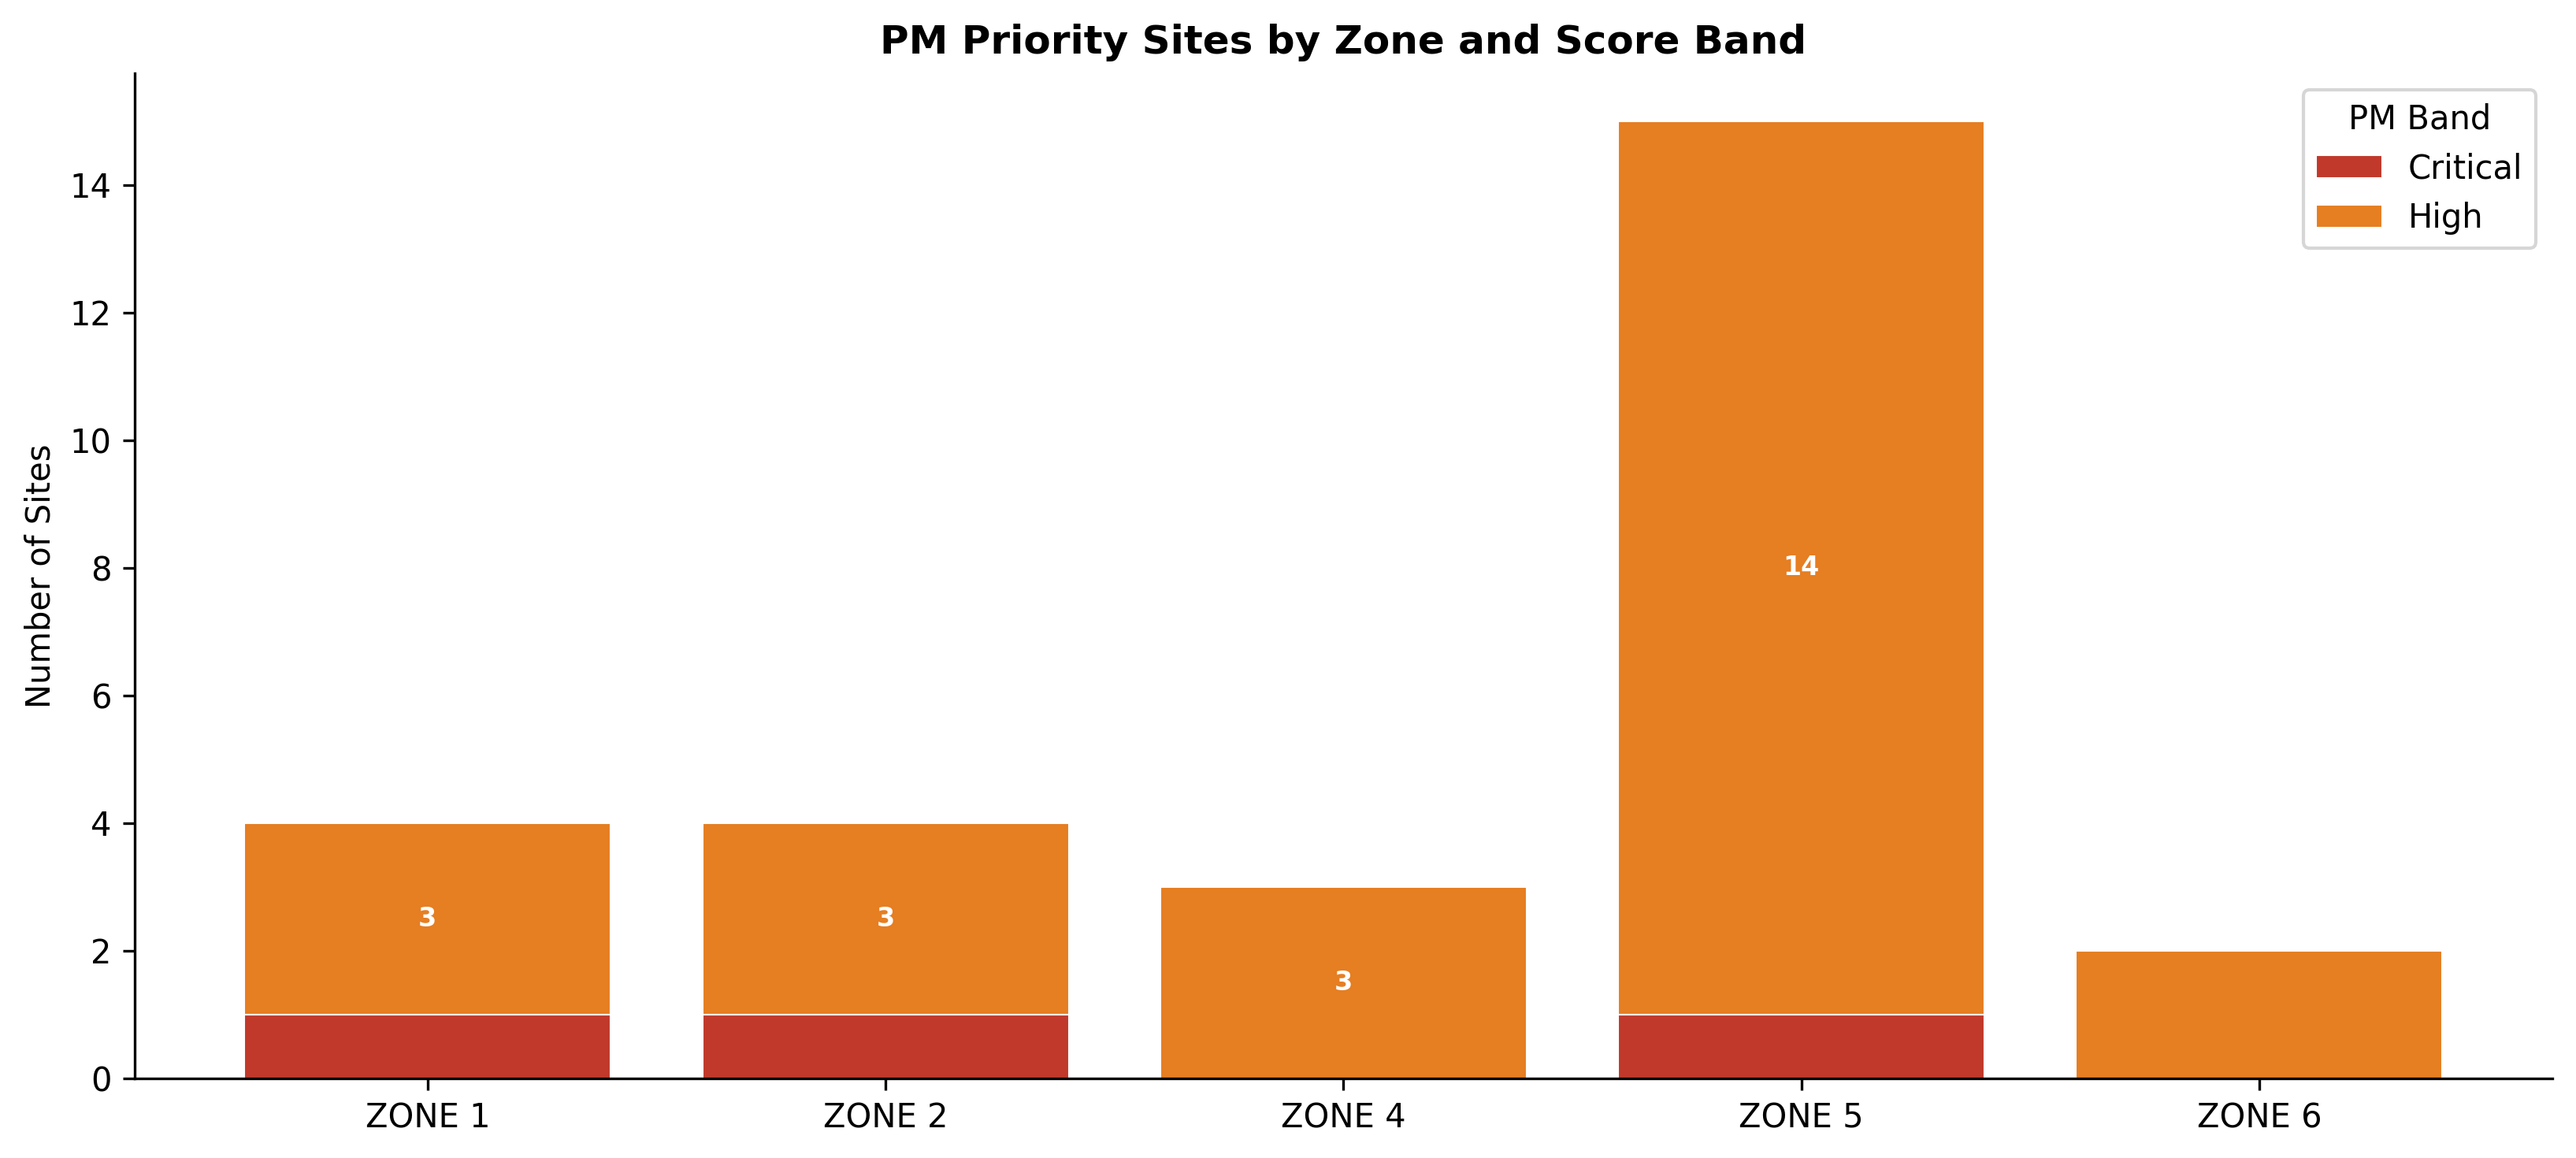

In [6]:
# ── Figure 7: PM score band distribution by zone ───────────────────────────────
if 'ZONE' in pm_queue.columns:
    band_zone = pm_queue.groupby(['ZONE', 'PM_Score_Band']).size().reset_index(name='Count')
    pivot_b = band_zone.pivot(index='ZONE', columns='PM_Score_Band', values='Count').fillna(0)
    band_order = ['Critical', 'High', 'Medium', 'Low']
    band_order = [b for b in band_order if b in pivot_b.columns]

    fig, ax = plt.subplots(figsize=(11, 5))
    bottom = np.zeros(len(pivot_b))
    for band in band_order:
        vals = pivot_b[band].values
        bars = ax.bar(pivot_b.index, vals, bottom=bottom, 
                      label=band, color=BAND_COLORS.get(band, '#aaa'),
                      edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, vals):
            if val >= 3:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_y() + bar.get_height()/2,
                        f'{int(val)}', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += vals

    ax.set_title('PM Priority Sites by Zone and Score Band', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Sites')
    ax.set_xlabel('')
    ax.legend(title='PM Band', loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/20_pm_workload_by_zone.png', dpi=DEFAULT_DPI, bbox_inches='tight')
    plt.show()

## 5. NE Types Driving PM-Priority Breaches

In [7]:
# Filter tickets to PM-priority sites only
pm_sites = set(pm_queue['SiteName']) if 'SiteName' in pm_queue.columns else set()
df_pm = df[df['SiteName'].isin(pm_sites)].copy()

ne_pm = df_pm.groupby('NEType').agg(
    Ticket_Count = ('OUTAGEDURATION', 'count'),
    Avg_MTTR     = ('OUTAGEDURATION', 'mean'),
    Breach_Rate  = ('SLA_Compliant',  lambda x: 1 - x.mean()),
).reset_index().sort_values('Breach_Rate', ascending=False)

print("Top NE types at PM-priority sites by breach rate (≥20 tickets):")
display(ne_pm[ne_pm['Ticket_Count'] >= 20].head(15)
        .style.format({'Avg_MTTR': '{:.1f}h', 'Breach_Rate': '{:.1%}'})
        .background_gradient(subset='Breach_Rate', cmap='YlOrRd'))

Top NE types at PM-priority sites by breach rate (≥20 tickets):


,NEType,Ticket_Count,Avg_MTTR,Breach_Rate
4,ENODEB,78,634.1h,73.1%
2,BTS,38,735.9h,71.1%


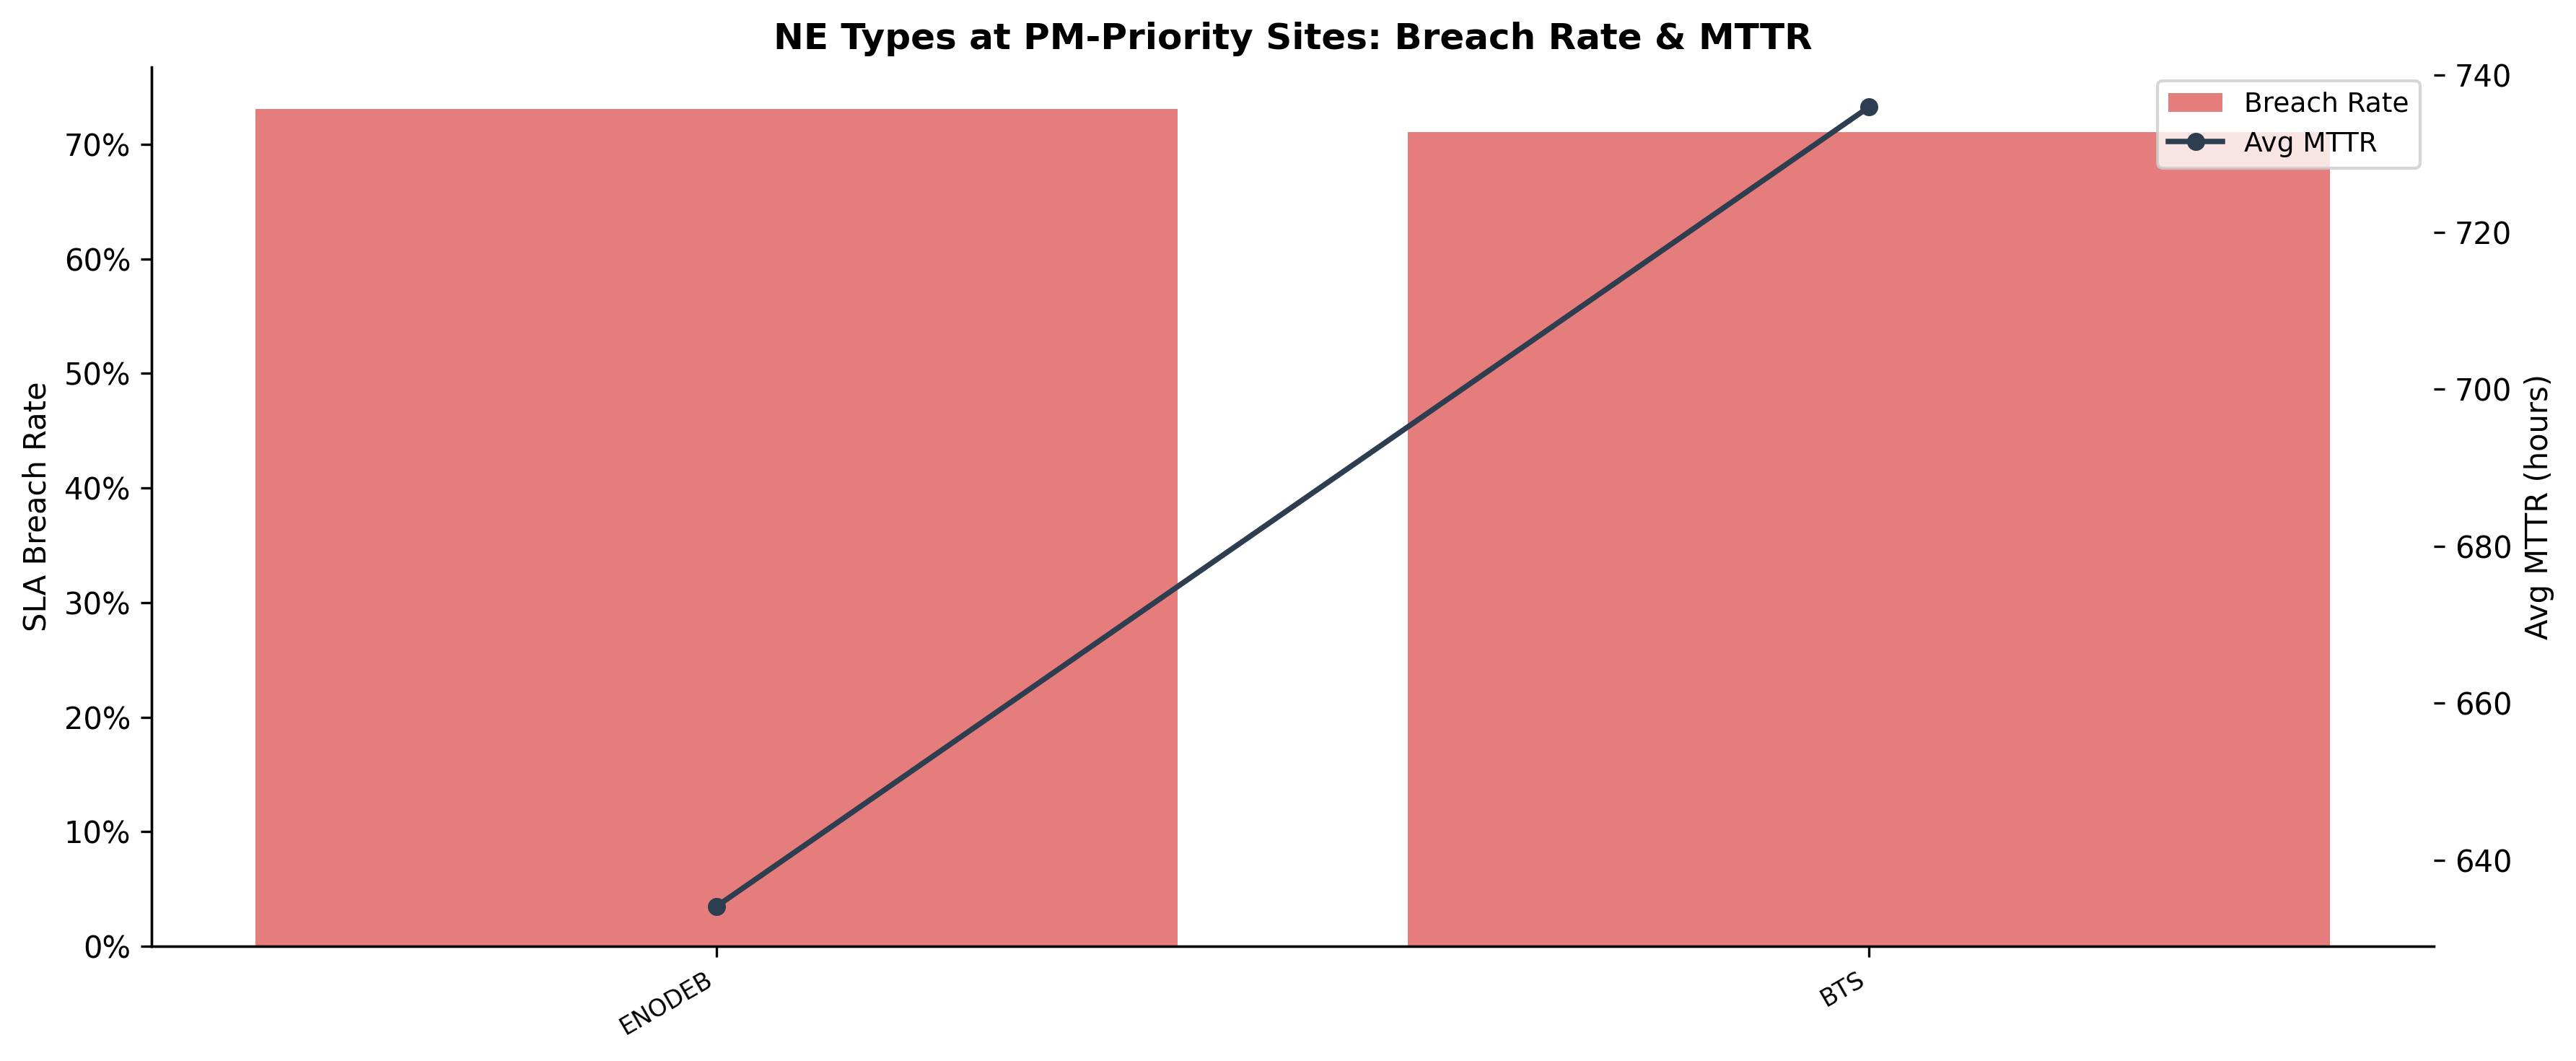

In [8]:
# ── Figure 8: Top 12 NE types at PM sites — breach rate & volume ───────────────
ne_pm_plot = ne_pm[ne_pm['Ticket_Count'] >= 20].head(12)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = range(len(ne_pm_plot))
bars = ax1.bar(x, ne_pm_plot['Breach_Rate'], color='#e05c5c', alpha=0.8, label='Breach Rate')
ax2.plot(x, ne_pm_plot['Avg_MTTR'], 'o-', color='#2c3e50', lw=1.8, ms=5, label='Avg MTTR')

ax1.set_xticks(list(x))
ax1.set_xticklabels(ne_pm_plot['NEType'], rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('SLA Breach Rate')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('Avg MTTR (hours)')
ax1.set_title('NE Types at PM-Priority Sites: Breach Rate & MTTR', fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/20_ne_types_pm_sites.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

## 6. Repeat-Failure Alignment Check

Do repeat-failure sites surface in the PM queue? If high-recurrence sites score low, the model needs recalibration.

In [9]:
repeat = identify_repeat_failures(df, min_tickets=3)

if 'SiteName' in repeat.columns and 'SiteName' in pm_queue.columns:
    top_repeat_sites = (
        repeat.groupby('SiteName')['Repeat_Ticket_Count']
        .sum()
        .reset_index()
        .sort_values('Repeat_Ticket_Count', ascending=False)
        .head(50)
    )
    in_queue = top_repeat_sites['SiteName'].isin(pm_queue['SiteName'])
    capture_rate = in_queue.mean()

    print(f"Top 50 repeat-failure sites captured in PM queue: {in_queue.sum()} / 50  ({capture_rate:.1%})")
    print()

    missed = top_repeat_sites[~in_queue]
    if not missed.empty:
        print("Sites with high repeat failures NOT in PM queue (may need score threshold review):")
        missed_with_score = missed.merge(
            site_scored[['SiteName','PM_Score','PM_Score_Band','Breach_Rate','Avg_MTTR']],
            on='SiteName', how='left'
        )
        display(missed_with_score.head(10).style.format({
            'PM_Score': '{:.1f}', 'Breach_Rate': '{:.1%}', 'Avg_MTTR': '{:.1f}h'
        }))
    else:
        print("All top repeat-failure sites captured — PM score model is well-calibrated.")

Top 50 repeat-failure sites captured in PM queue: 0 / 50  (0.0%)

Sites with high repeat failures NOT in PM queue (may need score threshold review):


,SiteName,Repeat_Ticket_Count,PM_Score,PM_Score_Band,Breach_Rate,Avg_MTTR
0,Region3_SAN JUAN CITY_b5b00bf5,1121,51.0,Medium,10.2%,81.2h
1,Region3_MAKATI CITY_89796080,1089,51.4,Medium,21.3%,34.1h
2,Region3_Unknown_Unknown,809,65.7,High,17.0%,100.9h
3,Region3_MAKATI CITY_e38bb3d3,492,38.1,Low,13.5%,5.7h
4,Region3_QUEZON CITY_2c40fd71,340,58.7,Medium,34.5%,68.6h
5,Region3_Unknown_ebc3e6c9,286,63.7,Medium,16.6%,393.8h
6,Region3_CALOOCAN CITY_712a8f02,174,69.7,High,29.2%,433.2h
7,Region3_QUEZON CITY_7a4de035,166,43.3,Low,21.8%,8.5h
8,Region3_Unknown_f49005a2,166,40.0,Low,13.2%,40.1h
9,Region3_CALOOCAN CITY_260e8b5e,130,66.9,High,26.2%,245.9h


## 7. PM Score Sensitivity — Threshold Analysis

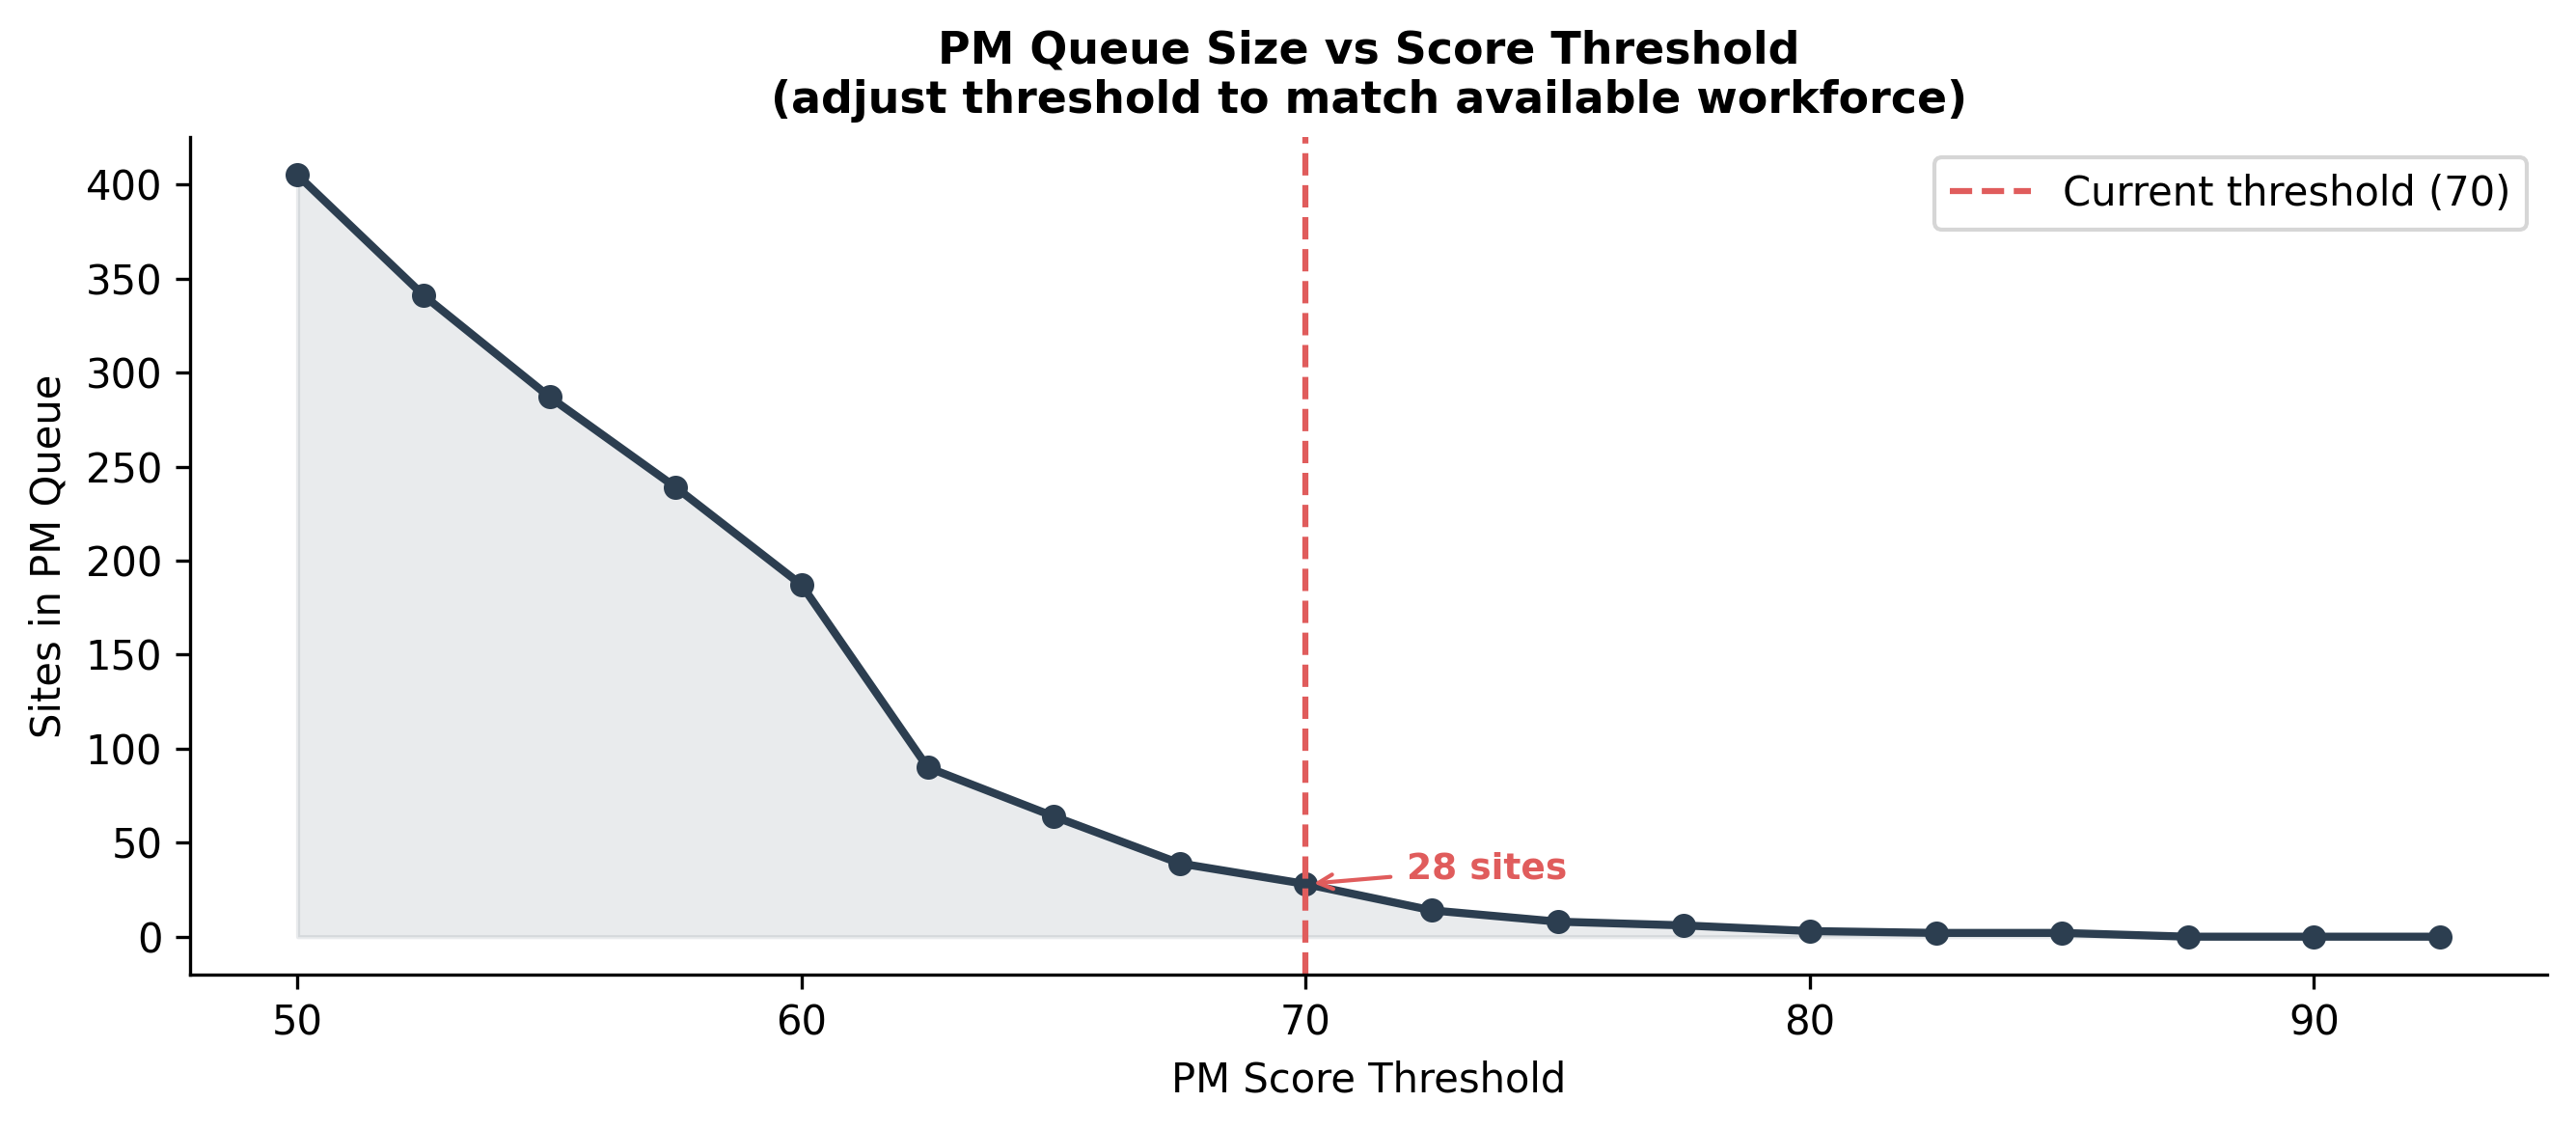

In [10]:
# ── Figure 9: Cumulative PM sites vs score threshold ──────────────────────────
thresholds = np.arange(50, 95, 2.5)
counts = [len(site_scored[site_scored['PM_Score'] >= t]) for t in thresholds]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, counts, 'o-', color='#2c3e50', lw=2, ms=5)
ax.axvline(70, color='#e05c5c', ls='--', lw=1.5, label='Current threshold (70)')
ax.fill_between(thresholds, counts, alpha=0.1, color='#2c3e50')

# Annotate current threshold count
current_count = len(site_scored[site_scored['PM_Score'] >= 70])
ax.annotate(f'{current_count} sites', xy=(70, current_count),
            xytext=(72, current_count + 3), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#e05c5c'),
            color='#e05c5c', fontweight='bold')

ax.set_xlabel('PM Score Threshold')
ax.set_ylabel('Sites in PM Queue')
ax.set_title('PM Queue Size vs Score Threshold\n(adjust threshold to match available workforce)',
             fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/20_pm_threshold_sensitivity.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

## 8. PM Score Distribution — Full Population

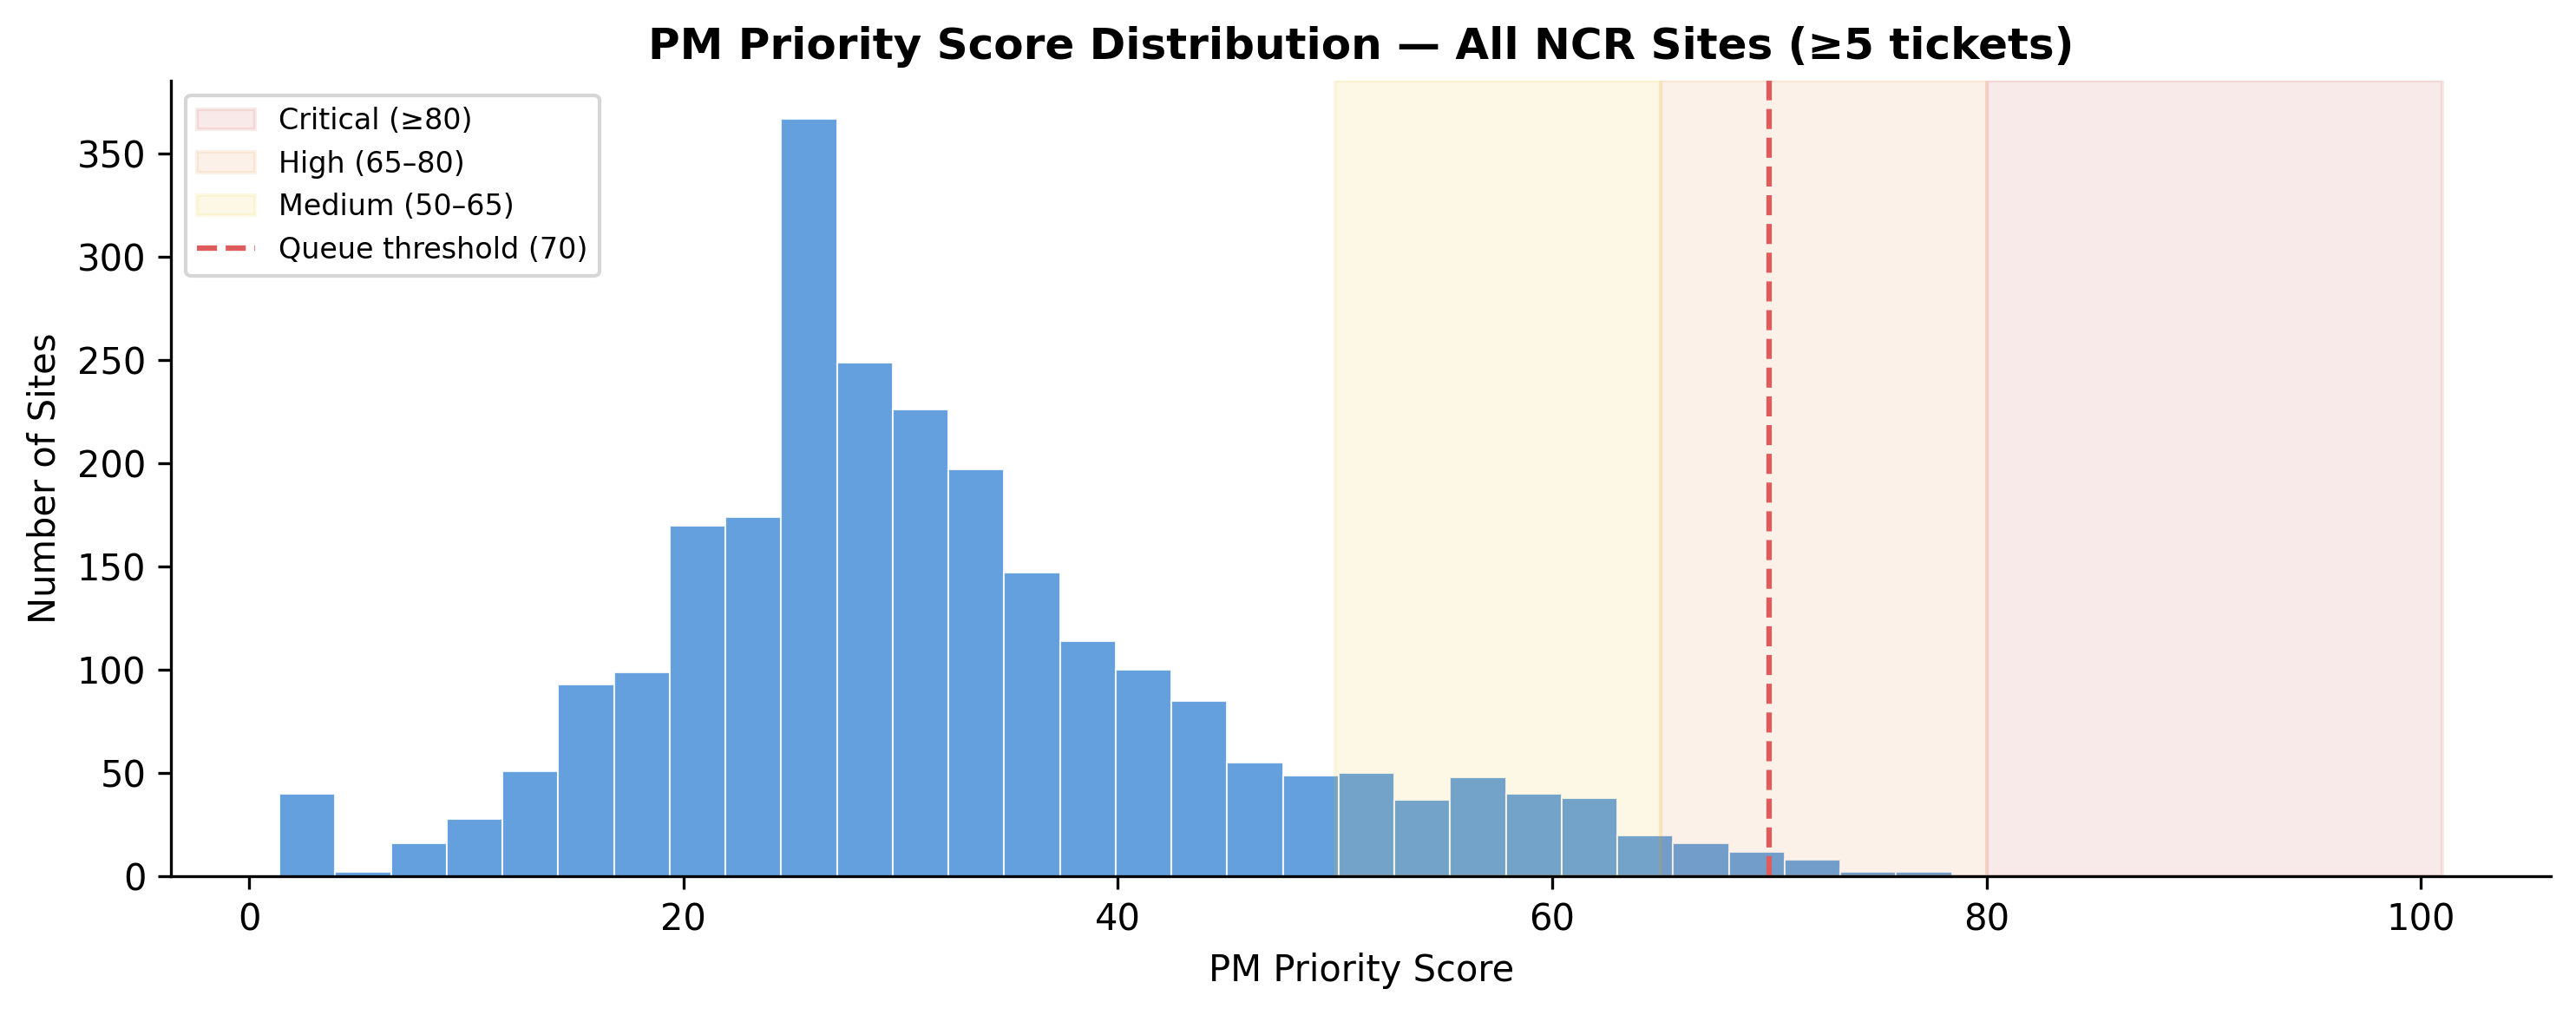

In [11]:
# ── Figure 10: PM score histogram with band shading ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

all_scores = site_scored[site_scored['Ticket_Count'] >= 5]['PM_Score']
ax.hist(all_scores, bins=30, color='#4a90d9', edgecolor='white', linewidth=0.5, alpha=0.85)

# Band shading
ax.axvspan(80, 101, alpha=0.1, color='#c0392b', label='Critical (≥80)')
ax.axvspan(65, 80,  alpha=0.1, color='#e67e22', label='High (65–80)')
ax.axvspan(50, 65,  alpha=0.1, color='#f1c40f', label='Medium (50–65)')
ax.axvline(70, color='#e05c5c', ls='--', lw=1.5, label='Queue threshold (70)')

ax.set_xlabel('PM Priority Score')
ax.set_ylabel('Number of Sites')
ax.set_title('PM Priority Score Distribution — All NCR Sites (≥5 tickets)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/20_pm_score_distribution.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

## 9. Key Findings

In [12]:
critical = pm_queue[pm_queue['PM_Score_Band'] == 'Critical']
high     = pm_queue[pm_queue['PM_Score_Band'] == 'High']
top_zone = zone_workload.sort_values('Critical_Sites', ascending=False).iloc[0] if 'ZONE' in pm_queue.columns else None
top_ne_breach = ne_pm[ne_pm['Ticket_Count'] >= 20].iloc[0]

print("="*70)
print("  PROJECT 6 — NB20 KEY FINDINGS")
print("="*70)
print(f"  PM queue (score ≥70)    : {len(pm_queue)} sites")
print(f"    Critical (score ≥80)  : {len(critical)} sites")
print(f"    High (score 65–79)    : {len(high)} sites")
if top_zone is not None:
    print(f"  Most critical zone      : {top_zone['ZONE']} "
          f"({int(top_zone['Critical_Sites'])} critical sites)")
print(f"  Worst NE breach @ PM sites: {top_ne_breach['NEType']} "
      f"({top_ne_breach['Breach_Rate']:.1%} breach, {top_ne_breach['Avg_MTTR']:.0f}h MTTR)")
if 'SiteName' in repeat.columns and 'SiteName' in pm_queue.columns:
    print(f"  Repeat-failure capture  : {capture_rate:.1%} of top-50 repeat sites in PM queue")
print(f"  Recommended threshold   : 70 (adjust to ~{thresholds[counts.index(min(counts, key=lambda c: abs(c-30)))]:.0f} for 30-site sprint)")
print("="*70)

  PROJECT 6 — NB20 KEY FINDINGS
  PM queue (score ≥70)    : 28 sites
    Critical (score ≥80)  : 3 sites
    High (score 65–79)    : 25 sites
  Most critical zone      : ZONE 1 (1 critical sites)
  Worst NE breach @ PM sites: ENODEB (73.1% breach, 634h MTTR)
  Repeat-failure capture  : 0.0% of top-50 repeat sites in PM queue
  Recommended threshold   : 70 (adjust to ~70 for 30-site sprint)
